# Simplify multipolygon
We are going to simplify a multipolygon:
- Simplify the multipolygon
- Make sure that the boundaries are respected

- import layers:
    -  multipolygon layer

- Documentation:
    - geopandas simplify: https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoSeries.simplify.html
    - shapely simplify: https://shapely.readthedocs.io/en/latest/manual.html#object.simplify

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Polygon, MultiPolygon, Point
from shapely.ops import snap
import os
from sys import path
import matplotlib.pyplot as plt
import topojson as tp

In [2]:
"""Read the input as a geodataframe"""
polygon_path = r"Z:\demo-geo-stack\geoserver\data\im-nca-botswana\botswana_boundaries\botswana_country_boundary_4326.shp"
# multipolygon_path = r"\\akif.internal\public\demo-geo-stack\geoserver\data\im-nca-southafrica\biomes\biomes_map_vectorized_4326_solved.shp"
gdf = gpd.read_file(polygon_path)

<AxesSubplot:>

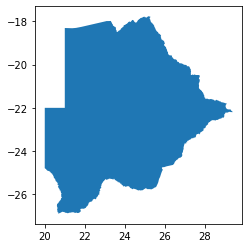

In [9]:
"""Simpification by topojson"""
unit = 0.005
topo = tp.Topology(gdf.to_crs(epsg='4326'), prequantize=False)
simplification = topo.toposimplify(unit).to_gdf()

simplification.plot()


In [ ]:
"""Export of the data"""
simplification.to_file(str(polygon_path[:]) + 'Arpae_precipitation_sum_of_emilia_romagna_{}.shp'.format(unit),index=False)

In [4]:
"""Simpification by Geopandas"""
gdf_simplified = gdf.simplify(100, preserve_topology=True)
# 7 minutes topology false
# 10 minutes topology true

In [ ]:
"""Check the validity"""
valid_list = gdf.is_valid

for x in valid_list:
    if x is True:
        print('We have a problem')
    else:
        pass